In [1]:
from qiskit import QuantumCircuit
from itertools import product
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import random

def cnot_sequence(circuit_length, input_bits='00'):
    c = QuantumCircuit(2)  # Specify the number of qubits (2 in this case)
    
    # Encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # Create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cx(0, 1)  # Use cx instead of cnot
        if idx % 2 == 1: c.cx(1, 0)  # Use cx instead of cnot
            
    return c

possible_input_bits      = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(product(possible_input_bits, possible_circuit_lengths))

circuit_pool             = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]

# Example circuit batch
print("EXAMPLE CIRCUIT BATCH")
print("_" * 24)
for key, circuit in generate_circuit_batch(5):
    print()
    print("input_bits={}, length={}".format(*key))
    print("-" * 24)
    print(circuit)
    print("_" * 24)

EXAMPLE CIRCUIT BATCH
________________________

input_bits=00, length=3
------------------------
          ┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └───┘     └───┘
________________________

input_bits=11, length=5
------------------------
     ┌───┐     ┌───┐     ┌───┐     
q_0: ┤ X ├──■──┤ X ├──■──┤ X ├──■──
     ├───┤┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├┤ X ├──■──┤ X ├──■──┤ X ├
     └───┘└───┘     └───┘     └───┘
________________________

input_bits=00, length=1
------------------------
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
________________________

input_bits=01, length=1
------------------------
               
q_0: ───────■──
     ┌───┐┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘
________________________

input_bits=11, length=6
------------------------
     ┌───┐     ┌───┐     ┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├──■──┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘
q_1: ┤ X ├┤ X ├──■──┤ X ├──■──┤ X ├──■──
     └───┘└───┘    

In [2]:
our_circuit= cnot_sequence(2, input_bits='01')

In [3]:
print(our_circuit)


               ┌───┐
q_0: ───────■──┤ X ├
     ┌───┐┌─┴─┐└─┬─┘
q_1: ┤ X ├┤ X ├──■──
     └───┘└───┘     


In [4]:
# The following is just a convenient little timer for things that take a while in the code below.
# I snipped it from https://medium.com/@DahlitzF/how-to-create-your-own-timing-context-manager-in-python-a0e944b48cf8

from time import time

class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        self.start = time()
    def __exit__(self, type, value, traceback):
        self.end = time()
        print(f"complete: {self.end - self.start:.3f}")

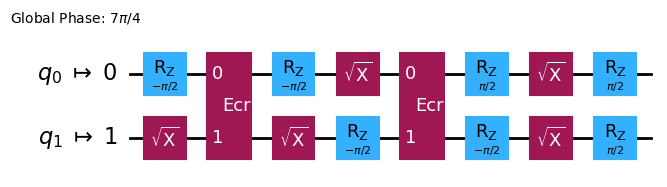

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

# If you did not previously save your credentials, use the following line instead:
service = QiskitRuntimeService(channel="ibm_quantum", token="cc58d7cdf1020b6241a0eda66432f35dcc2529f7c9a15681e2ef718591167c3aa9ce4f617dacfef4eea35eb9641bda1ad5bff0fb45bcbe2035ad04af97f0fc63")
#service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(our_circuit)

isa_circuit.draw('mpl', idle_wires=False)


In [6]:
!pip install qiskit-aer


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
from qiskit_aer import AerSimulator


In [8]:
import qiskit
print(qiskit.__version__)

1.2.1


In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import itertools as it
import random
from time import time

# Define Timer class
class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        self.start = time()
    def __exit__(self, type, value, traceback):
        self.end = time()
        print(f"{self.description} complete: {self.end - self.start:.3f}s")  

# Define the CNOT sequence generator
def cnot_sequence(circuit_length, input_bits='00'):
    c = QuantumCircuit(2, 2)  # Create a 2-qubit, 2-classical-bit circuit
    
    # Encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # Create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cx(0, 1)
        if idx % 2 == 1: c.cx(1, 0)
    
    # Add measurement to classical bits
    c.measure([0, 1], [0, 1])
    return c

# Define possible input bits and circuit lengths
possible_input_bits = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

# Generate circuit pool
circuit_pool = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

# Function to generate random circuit batches
def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]

# Simulate and create reference table
reference_table = {}
simulator = AerSimulator()  # Use AerSimulator

for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)]
        print(f"Starting simulation: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("Simulation"):
            # Execute the circuit on the simulator
            job = simulator.run(circuit_to_simulate, shots=1000)  # Use a higher number of shots for better statistics
            result = job.result()
            
            # Extract measurement probabilities
            counts = result.get_counts(circuit_to_simulate)
            total_counts = sum(counts.values())
            probabilities = {k: v / total_counts for k, v in counts.items()}
            
            # Store the probabilities in the reference table
            reference_table[(input_bits, circuit_length)] = probabilities

# Display the reference table
print("\nReference Table (Probabilities):")
for input_bits in possible_input_bits:
    print(f"Input Bits: {input_bits}")
    for circuit_length in possible_circuit_lengths:
        probabilities = reference_table[(input_bits, circuit_length)]
        print(f"  Circuit Length {circuit_length}: {probabilities}")

# Generate a test batch of circuits
test_batch = generate_circuit_batch(100)

# Simulate test batch
test_results = []

for key, circuit in test_batch:
    job = simulator.run(circuit, shots=100)  # Run with the defined number of shots
    result = job.result()
    counts = result.get_counts(circuit)
    
    # Calculate probabilities
    total_counts = sum(counts.values())
    probabilities = {k: v / total_counts for k, v in counts.items()}
    
    test_results.append((key, probabilities))
    
# Display test results
print("\nTest Batch Results (Probabilities):")
for (key, probabilities) in test_results[:10]:  # Show first 10 results as an example
    print(f"Key: {key}")
    print("Probabilities:", probabilities)


Starting simulation: input_bits=00, circuit_length=1... Simulation complete: 0.002s
Starting simulation: input_bits=00, circuit_length=2... Simulation complete: 0.002s
Starting simulation: input_bits=00, circuit_length=3... Simulation complete: 0.002s
Starting simulation: input_bits=00, circuit_length=4... Simulation complete: 0.001s
Starting simulation: input_bits=00, circuit_length=5... Simulation complete: 0.001s
Starting simulation: input_bits=00, circuit_length=6... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=1... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=2... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=3... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=4... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=5... Simulation complete: 0.001s
Starting simulation: input_bits=01, circuit_length=6... Simulation complete:

In [10]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import itertools as it
import random
from time import time
import pandas as pd

# Define Timer class
class Timer:
    def __init__(self, description):
        self.description = description
        self.start = None  # Ensure attributes are always initialized
        self.end = None
        self.elapsed_time = None
    
    def __enter__(self):
        self.start = time()
        return self  # Return the Timer object to access its attributes later
    
    def __exit__(self, type, value, traceback):
        self.end = time()
        self.elapsed_time = self.end - self.start if self.start else None
        print(f"{self.description} complete: {self.elapsed_time:.3f}s")  

# Define the CNOT sequence generator
def cnot_sequence(circuit_length, input_bits='00'):
    c = QuantumCircuit(2, 2)  # Create a 2-qubit, 2-classical-bit circuit
    
    # Encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # Create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cx(0, 1)
        if idx % 2 == 1: c.cx(1, 0)
    
    # Add measurement to classical bits
    c.measure([0, 1], [0, 1])
    return c

# Define possible input bits and circuit lengths
possible_input_bits = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

# Generate circuit pool
circuit_pool = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

# Simulate and create reference table
reference_table = {}
simulator = AerSimulator()  # Use AerSimulator

for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)]
        print(f"Starting simulation: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("Simulation") as timer:
            # Execute the circuit on the simulator
            job = simulator.run(circuit_to_simulate, shots=100)  # Use a higher number of shots for better statistics
            result = job.result()
            
            # Extract measurement probabilities
            counts = result.get_counts(circuit_to_simulate)
            total_counts = sum(counts.values())
            probabilities = {k: v / total_counts for k, v in counts.items()}
            
            # Find the most probable output as the "correct" output
            correct_output = max(probabilities, key=probabilities.get)
            reference_table[(input_bits, circuit_length)] = {
                "probabilities": probabilities,
                "correct_output": correct_output
            }

# Generate a test batch of circuits
def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]

test_batch = generate_circuit_batch(100)

# Simulate test batch and compute additional data
data = []

for idx, (key, circuit) in enumerate(test_batch):
    input_bits, circuit_length = key
    print(f"Simulating test circuit {idx + 1}/{len(test_batch)}: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
    
    with Timer("Test simulation") as timer:
        try:
            # Execute the circuit on the simulator
            job = simulator.run(circuit, shots=100)
            result = job.result()
            counts = result.get_counts(circuit)
            total_counts = sum(counts.values())
            probabilities = {k: v / total_counts for k, v in counts.items()}
            
            # Extract the correct output and its success probability
            correct_output = reference_table[key]["correct_output"]
            success_probability = probabilities.get(correct_output, 0)
        
        except Exception as e:
            print(f"Error during simulation: {e}")
            success_probability = None
        
        # Record data, handling cases where timer attributes might not exist
        data.append({
            "input_bits": input_bits,
            "circuit_length": circuit_length,
            "start_time": timer.start,
            "end_time": timer.end if timer.end else "N/A",  # Fallback for end_time
            "elapsed_time": timer.elapsed_time if timer.elapsed_time else "N/A",  # Fallback for elapsed_time
            "success_probability": success_probability
        })
        print("Done.")

# Convert data to DataFrame
df = pd.DataFrame(data)
print("\nSimulation DataFrame:")
print(df.head())

Starting simulation: input_bits=00, circuit_length=1... Simulation complete: 0.001s
Starting simulation: input_bits=00, circuit_length=2... Simulation complete: 0.000s
Starting simulation: input_bits=00, circuit_length=3... Simulation complete: 0.000s
Starting simulation: input_bits=00, circuit_length=4... Simulation complete: 0.000s
Starting simulation: input_bits=00, circuit_length=5... Simulation complete: 0.000s
Starting simulation: input_bits=00, circuit_length=6... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=1... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=2... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=3... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=4... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=5... Simulation complete: 0.000s
Starting simulation: input_bits=01, circuit_length=6... Simulation complete:

In [11]:
available_backends = service.backends()
print(available_backends)

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_kyiv')>, <IBMBackend('ibm_sherbrooke')>]


In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import Sampler
from time import time
import itertools as it
import random
from collections import Counter

# Initialize the IBM Quantum Runtime Service
service = QiskitRuntimeService(
    channel="ibm_quantum", 
    token="cc58d7cdf1020b6241a0eda66432f35dcc2529f7c9a15681e2ef718591167c3aa9ce4f617dacfef4eea35eb9641bda1ad5bff0fb45bcbe2035ad04af97f0fc63"  # Replace with your actual token
)

# Select the least busy quantum device
backend = service.least_busy(simulator=False, operational=True)
print(f"Selected backend: {backend.name}")

# Define Timer class
class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        self.start = time()
    def __exit__(self, type, value, traceback):
        self.end = time()
        print(f"{self.description} complete: {self.end - self.start:.3f}s")  

# Define the CNOT sequence generator
def cnot_sequence(circuit_length, input_bits='00'):
    c = QuantumCircuit(2, 2)  # Create a 2-qubit, 2-classical-bit circuit
    
    # Encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # Create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cx(0, 1)
        if idx % 2 == 1: c.cx(1, 0)
    
    # Add measurement to classical bits
    c.measure([0, 1], [0, 1])
    return c

# Define possible input bits and circuit lengths
possible_input_bits = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

# Generate circuit pool
circuit_pool = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

# Function to generate random circuit batches
#def generate_circuit_batch(size):
    #random_keys = random.choices(possible_keys, k=size)
    #return [(key, circuit_pool[key]) for key in random_keys]

# Simulate and create reference table using Sampler
reference_table = {}

# Debug: Check backend status
print(f"Selected backend: {backend.name}, Operational: {backend.status().operational}")

# Create the Sampler instance
sampler = Sampler(backend=backend)

# Iterate through input bits and circuit lengths
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)]
        print(f"Starting execution on backend: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")

        # Transpile the circuit to match the backend's architecture
        transpiled_circuit = transpile(circuit_to_simulate, backend=backend)
           

        # Run the transpiled circuit using the sampler
        result = sampler.run([transpiled_circuit], shots=100).result()
        
        bit_array = result._pub_results[0].data.c

        # Extract the bitstrings using the get_bitstrings method
        bit_strings = bit_array.get_bitstrings()

        # Count occurrences of each measurement outcome
        counts = Counter(bit_strings)

        # Calculate total counts and probabilities
        total_counts = sum(counts.values())
        probabilities = {k: v / total_counts for k, v in counts.items()}
        
        # Find the most probable output as the "correct" output
        correct_output = max(probabilities, key=probabilities.get)
        reference_table[(input_bits, circuit_length)] = {"probabilities": probabilities,
                                                         "correct_output": correct_output}

        print("Done.")

# Display the reference table
print("\nReference Table (Probabilities):")







Selected backend: ibm_brisbane
Selected backend: ibm_brisbane, Operational: True
Starting execution on backend: input_bits=00, circuit_length=1... 

/var/folders/fw/cmkfy94n4v575qmrlq1fq5qm0000gn/T/ipykernel_15656/1019385008.py:70: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


Done.
Starting execution on backend: input_bits=00, circuit_length=2... Done.
Starting execution on backend: input_bits=00, circuit_length=3... Done.
Starting execution on backend: input_bits=00, circuit_length=4... Done.
Starting execution on backend: input_bits=00, circuit_length=5... Done.
Starting execution on backend: input_bits=00, circuit_length=6... Done.
Starting execution on backend: input_bits=01, circuit_length=1... Done.
Starting execution on backend: input_bits=01, circuit_length=2... Done.
Starting execution on backend: input_bits=01, circuit_length=3... Done.
Starting execution on backend: input_bits=01, circuit_length=4... Done.
Starting execution on backend: input_bits=01, circuit_length=5... Done.
Starting execution on backend: input_bits=01, circuit_length=6... Done.
Starting execution on backend: input_bits=10, circuit_length=1... Done.
Starting execution on backend: input_bits=10, circuit_length=2... Done.
Starting execution on backend: input_bits=10, circuit_leng

qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:27:29,230: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cymrwf19b62g0082x8eg', 'sampler')> to finish before submitting the next one.
qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:27:36,770: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cymrwgtrta1g008w0kv0', 'sampler')> to finish before submitting the next one.
qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:27:46,029: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cymrwka7v8tg008y6820', 'sampler')> to finish before submitting the next one.


Executing batch complete: 25.408s


AttributeError: 'PrimitiveResult' object has no attribute 'quasi_dists'

In [23]:
# Generate test batch
def generate_circuit_batch(size):
    return [(key, circuit_pool[key]) for key in random.choices(list(circuit_pool.keys()), k=size)]

test_batch = generate_circuit_batch(10)
print("Generated test batch.")

# Run batch on IBM backend
tasks = []
with Timer("Executing batch"):
    for key, circuit in test_batch:
        transpiled_circuit = transpile(circuit, backend=backend)
        task = sampler.run([transpiled_circuit], shots=100)
        tasks.append((key, task))

# Collect results
data = []
for key, task in tasks:
    result = task.result()
    
    # Extract bitstrings using the same method as before
    bit_array = result._pub_results[0].data.c
    bit_strings = bit_array.get_bitstrings()

    # Count occurrences of each measurement outcome
    counts = Counter(bit_strings)
    
    # Calculate total counts and probabilities
    total_counts = sum(counts.values())
    probabilities = {k: v / total_counts for k, v in counts.items()}

    # Retrieve the correct output from reference_table
    correct_output = reference_table[key]["correct_output"]

    # Get the probability of the correct output
    success_probability = probabilities.get(correct_output, 0)
    
    data.append((key[0], key[1], success_probability))

data_df = pd.DataFrame(data, columns=['input_bits', 'circuit_length', 'success_probability'])
print("Execution complete. Data collected.")


Generated test batch.


qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:53:01,643: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cyms8e1cw2k00089w760', 'sampler')> to finish before submitting the next one.
qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:53:06,164: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cyms8fhnrmz0008twr40', 'sampler')> to finish before submitting the next one.
qiskit_runtime_service.check_pending_jobs:WARNING:2025-02-09 21:53:13,402: The pending jobs limit has been reached. Waiting for job <RuntimeJob('cyms8h27v8tg008y69s0', 'sampler')> to finish before submitting the next one.


Executing batch complete: 22.822s
Execution complete. Data collected.


In [24]:
data_df

,input_bits,circuit_length,success_probability
0,01,2,0.75
1,00,4,0.71
2,11,4,0.70
3,10,2,0.76
4,00,6,0.56
5,00,4,0.63
6,10,3,0.78
7,11,3,0.75
8,00,2,0.76
9,10,1,0.88


In [25]:
data_df.to_csv("success_probability_qiskit.csv")

In [19]:
import json
# Convert tuple keys to strings
dict_to_save = {str(k): v for k, v in reference_table.items()}
with open("refrence_table.json", "w") as file:
    json.dump(dict_to_save, file, indent=4)  

In [16]:
reference_table.

{('00', 1): {'probabilities': {'10': 0.11, '00': 0.8, '01': 0.08, '11': 0.01},
  'correct_output': '00'},
 ('00', 2): {'probabilities': {'01': 0.06, '00': 0.71, '10': 0.09, '11': 0.14},
  'correct_output': '00'},
 ('00', 3): {'probabilities': {'11': 0.04, '00': 0.62, '10': 0.12, '01': 0.22},
  'correct_output': '00'},
 ('00', 4): {'probabilities': {'01': 0.19, '10': 0.1, '00': 0.63, '11': 0.08},
  'correct_output': '00'},
 ('00', 5): {'probabilities': {'11': 0.13, '10': 0.15, '00': 0.49, '01': 0.23},
  'correct_output': '00'},
 ('00', 6): {'probabilities': {'00': 0.51, '01': 0.23, '11': 0.17, '10': 0.09},
  'correct_output': '00'},
 ('01', 1): {'probabilities': {'00': 0.11, '11': 0.12, '10': 0.77},
  'correct_output': '10'},
 ('01', 2): {'probabilities': {'10': 0.05, '11': 0.79, '00': 0.14, '01': 0.02},
  'correct_output': '11'},
 ('01', 3): {'probabilities': {'01': 0.78, '00': 0.07, '10': 0.05, '11': 0.1},
  'correct_output': '01'},
 ('01', 4): {'probabilities': {'10': 0.06, '11': 0.1

In [122]:
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
 
# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
# Run the sampler job locally using AerSimulator.
# Session syntax is supported but ignored because local mode doesn't support sessions.
aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc = pm.run(qc)
with Session(backend=aer_sim) as session:
    sampler = Sampler(mode=session)
    result = sampler.run([isa_qc]).result()

In [126]:
print (result[0].data.meas)

BitArray(<shape=(), num_shots=1024, num_bits=2>)


In [110]:
result[0].data.meas.get_counts()


{'11': 492, '00': 532}

In [127]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
import itertools as it
import random
import pandas as pd
from time import time

# Define Timer class
class Timer:
    def __init__(self, description):
        self.description = description
        self.start = None
        self.end = None
        self.elapsed_time = None
    
    def __enter__(self):
        self.start = time()
        return self  
    
    def __exit__(self, type, value, traceback):
        self.end = time()
        self.elapsed_time = self.end - self.start if self.start else None
        print(f"{self.description} complete: {self.elapsed_time:.3f}s")  

# Define the CNOT sequence generator
def cnot_sequence(circuit_length, input_bits='00'):
    c = QuantumCircuit(2, 2)  
    
    # Encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # Create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cx(0, 1)
        if idx % 2 == 1: c.cx(1, 0)
    
    c.measure([0, 1], [0, 1])
    return c

# Define possible input bits and circuit lengths
possible_input_bits = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = [(str(bits), length) for bits, length in it.product(possible_input_bits, possible_circuit_lengths)]


# Generate circuit pool
circuit_pool = {key: cnot_sequence(key[1], key[0]) for key in possible_keys}


# Simulate and create reference table
reference_table = {}
aer_sim = AerSimulator()

# Preprocess circuits using preset pass manager
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
processed_circuits = {key: pm.run(circuit) for key, circuit in circuit_pool.items()}

with Session(backend=aer_sim) as session:
    sampler = Sampler(session)
    
    for key, circuit in processed_circuits.items():
        input_bits, circuit_length = key
        print(f"Starting simulation: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("Simulation") as timer:
            result = sampler.run([circuit]).result()
            print (result[0])
            probabilities = result[0]

            
            # Find the most probable output as the "correct" output
            correct_output = max(probabilities, key=probabilities.get)
            reference_table[key] = {
                "probabilities": probabilities,
                "correct_output": correct_output
            }

# Generate a test batch of circuits
def generate_circuit_batch(size):
    return random.choices(possible_keys, k=size)

test_batch = generate_circuit_batch(100)

# Simulate test batch and compute additional data
data = []

with Session(backend=aer_sim) as session:
    sampler = Sampler(session)
    
    for idx, key in enumerate(test_batch):
        input_bits, circuit_length = key
        circuit = processed_circuits[key]
        print(f"Simulating test circuit {idx + 1}/{len(test_batch)}: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("Test simulation") as timer:
            try:
                result = sampler.run([circuit]).result()
                probabilities = result.quasi_dists[0]
                correct_output = reference_table[key]["correct_output"]
                success_probability = probabilities.get(correct_output, 0)
            except Exception as e:
                print(f"Error during simulation: {e}")
                success_probability = None
            
            data.append({
                "input_bits": input_bits,
                "circuit_length": circuit_length,
                "start_time": timer.start,
                "end_time": timer.end if timer.end else "N/A",
                "elapsed_time": timer.elapsed_time if timer.elapsed_time else "N/A",
                "success_probability": success_probability
            })
            print("Done.")

# Convert data to DataFrame
df = pd.DataFrame(data)
print("\nSimulation DataFrame:")
print(df.head())
        

Starting simulation: input_bits=00, circuit_length=1... SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})
Simulation complete: 0.003s


AttributeError: 'SamplerPubResult' object has no attribute 'get'

In [149]:
print(dir(result))

['__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_is_protocol', '_metadata', '_pub_results', 'metadata']


In [150]:
print(result._pub_results)


[SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=10, num_bits=2>)), metadata={'circuit_metadata': {}})]


In [157]:
# Inspect the BitArray object directly to understand its contents
bit_array = result._pub_results[0].data.c

# Check the contents directly
print("BitArray content:", bit_array)

# If it's a single object with an internal structure, attempt to print out its properties or methods
print("BitArray properties:", dir(bit_array))

BitArray content: BitArray(<shape=(), num_shots=10, num_bits=2>)
BitArray properties: ['__abstractmethods__', '__and__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '__xor__', '_abc_impl', '_array', '_bytes_to_bitstring', '_bytes_to_int', '_get_counts', '_is_protocol', '_is_runtime_protocol', '_num_bits', '_prepare_broadcastable', '_shape', 'array', 'bitcount', 'concatenate', 'concatenate_bits', 'concatenate_shots', 'expectation_values', 'from_bool_array', 'from_counts', 'from_samples', 'get_bitstrings', 'get_counts', 'get_int_counts', 'ndim', 'num_bits', 'num_shots',

In [158]:
# Extract the bitstrings using the get_bitstrings method
bit_strings = bit_array.get_bitstrings()

# Print out the bitstrings to inspect
print("Bitstrings:", bit_strings)

# Count occurrences of each measurement outcome
from collections import Counter
counts = Counter(bit_strings)

# Print the counts
print("Counts:", counts)

Bitstrings: ['00', '00', '00', '00', '00', '00', '00', '00', '00', '00']
Counts: Counter({'00': 10})
